## IMPORT LIBRARIES

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
%matplotlib
import mysql.connector

Using matplotlib backend: module://matplotlib_inline.backend_inline


## IMPORT DATA FROM MYSQL

In [2]:
cnx = mysql.connector.connect(
    host="127.0.0.1",
    port=3306,
    user="root",
    password="root")

In [3]:
query = "select * from banking_case.customer"

In [4]:
data = pd.read_sql(query, cnx)

In [5]:
cnx.close()

## BASIC CHECKS

In [6]:
data.shape

(3000, 25)

In [7]:
data.head(5)

,ï»¿Client ID,Name,Age,Location ID,Joined Bank,Banking Contact,Nationality,Occupation,Fee Structure,Loyalty Classification,...,Bank Deposits,Checking Accounts,Saving Accounts,Foreign Currency Account,Business Lending,Properties Owned,Risk Weighting,BRId,GenderId,IAId
0,IND81288,Raymond Mills,24,34324,06-05-2019,Anthony Torres,American,Safety Technician IV,High,Jade,...,1485828.64,603617.88,607332.46,12249.96,1134475.30,1,2,1,1,1
1,IND65833,Julia Spencer,23,42205,10-12-2001,Jonathan Hawkins,African,Software Consultant,High,Jade,...,641482.79,229521.37,344635.16,61162.31,2000526.10,1,3,2,1,2
2,IND47499,Stephen Murray,27,7314,25-01-2010,Anthony Berry,European,Help Desk Operator,High,Gold,...,1033401.59,652674.69,203054.35,79071.78,548137.58,1,3,3,2,3
3,IND72498,Virginia Garza,40,34594,28-03-2019,Steve Diaz,American,Geologist II,Mid,Silver,...,1048157.49,1048157.49,234685.02,57513.65,1148402.29,0,4,4,1,4
4,IND60181,Melissa Sanders,46,41269,20-07-2012,Shawn Long,American,Assistant Professor,Mid,Platinum,...,487782.53,446644.25,128351.45,30012.14,1674412.12,0,3,1,2,5


In [8]:
data.tail()

,ï»¿Client ID,Name,Age,Location ID,Joined Bank,Banking Contact,Nationality,Occupation,Fee Structure,Loyalty Classification,...,Bank Deposits,Checking Accounts,Saving Accounts,Foreign Currency Account,Business Lending,Properties Owned,Risk Weighting,BRId,GenderId,IAId
2995,IND66827,Earl Hall,82,8760,09-10-2014,Joshua Bennett,American,Accounting Assistant III,High,Gold,...,1089957.03,532867.88,657849.62,12947.31,1238859.91,1,3,3,2,4
2996,IND40556,Billy Williamson,44,32837,05-02-2009,Dennis Ruiz,European,Paralegal,Mid,Gold,...,136891.32,56581.74,93195.61,23205.69,277171.07,1,2,3,2,5
2997,IND72414,Victor Black,70,36088,29-12-2009,Joshua Ryan,American,Statistician IV,Low,Jade,...,214860.89,158726.06,35539.15,30291.81,502947.22,2,2,3,2,6
2998,IND46652,Andrew Ford,56,24871,13-02-2006,Nicholas Cunningham,European,Human Resources Assistant III,Mid,Jade,...,742630.22,404638.26,56411.33,6413.14,1538368.60,3,1,3,2,7
2999,IND40216,Amy Nguyen,79,38518,08-12-2005,Joe Hanson,American,Biostatistician III,High,Jade,...,65617.66,77769.08,32371.38,8992.36,329412.55,1,1,3,2,8


In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 25 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ï»¿Client ID              3000 non-null   object 
 1   Name                      3000 non-null   object 
 2   Age                       3000 non-null   int64  
 3   Location ID               3000 non-null   int64  
 4   Joined Bank               3000 non-null   object 
 5   Banking Contact           3000 non-null   object 
 6   Nationality               3000 non-null   object 
 7   Occupation                3000 non-null   object 
 8   Fee Structure             3000 non-null   object 
 9   Loyalty Classification    3000 non-null   object 
 10  Estimated Income          3000 non-null   float64
 11  Superannuation Savings    3000 non-null   float64
 12  Amount of Credit Cards    3000 non-null   int64  
 13  Credit Card Balance       3000 non-null   float64
 14  Bank Loa

In [10]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,3000.0,51.039667,19.854760,17.00,34.0000,51.000,6.900000e+01,85.00
Location ID,3000.0,21563.323000,12462.273017,12.00,10803.5000,21129.500,3.205450e+04,43369.00
Estimated Income,3000.0,171305.034263,111935.808209,15919.48,82906.5950,142313.480,2.422903e+05,522330.26
Superannuation Savings,3000.0,25531.599673,16259.950770,1482.03,12513.7750,22357.355,3.546474e+04,75963.90
Amount of Credit Cards,3000.0,1.463667,0.676387,1.00,1.0000,1.000,2.000000e+00,3.00
Credit Card Balance,3000.0,3176.206943,2497.094709,1.17,1236.6300,2560.805,4.522632e+03,13991.99
Bank Loans,3000.0,591386.155487,457557.036334,0.00,239628.1375,479793.400,8.258130e+05,2667556.66
Bank Deposits,3000.0,671560.193923,645716.856875,0.00,204400.3750,463316.460,9.427546e+05,3890598.08
Checking Accounts,3000.0,321092.949127,282079.553893,0.00,119947.5300,242815.655,4.348749e+05,1969923.08
Saving Accounts,3000.0,232908.353483,230007.777498,0.00,74794.4050,164086.555,3.155750e+05,1724118.36


In [11]:
data.describe(include = "all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ï»¿Client ID,3000,2940,IND48103,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Name,3000,2913,Jeremy Alexander,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,3000.0,NaN,NaN,NaN,51.039667,19.85476,17.0,34.0,51.0,69.0,85.0
Location ID,3000.0,NaN,NaN,NaN,21563.323,12462.273017,12.0,10803.5,21129.5,32054.5,43369.0
Joined Bank,3000,2579,19-06-2020,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Banking Contact,3000,49,Ernest Rivera,77,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Nationality,3000,5,European,1309,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Occupation,3000,195,Associate Professor,28,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fee Structure,3000,3,High,1476,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Loyalty Classification,3000,4,Jade,1331,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## FEATURE ENGINEERING

In [12]:
bins = [1, 100000, 300000, float("inf")]
labels = ["low", "mid", "high"]
data["Income band"] = pd.cut(data["Estimated Income"], bins = bins, labels = labels, right = False)

In [31]:
# Identify the categorical column and check the value count for each of it
categorical_col = data[["BRId", "GenderId", "Amount of Credit Cards", "Nationality", "Fee Structure"
                       , "Loyalty Classification", "Properties Owned", "Risk Weighting","Income band", "IAId"]].columns

In [32]:
for col in categorical_col:
    display(f"Value count of: {col}")
    display(data[col].value_counts().to_frame())

'Value count of: BRId'

,count
BRId,
3,1352
1,660
2,495
4,493


'Value count of: GenderId'

,count
GenderId,
2,1512
1,1488


'Value count of: Amount of Credit Cards'

...

,count
Risk Weighting,
2,1222
1,836
3,460
4,322
5,160


'Value count of: Income band'

,count
Income band,
mid,1517
low,1027
high,456


'Value count of: IAId'

,count
IAId,
1,177
2,177
3,177
4,177
8,177
9,176
13,176
12,176
10,176


## Univariant analysis

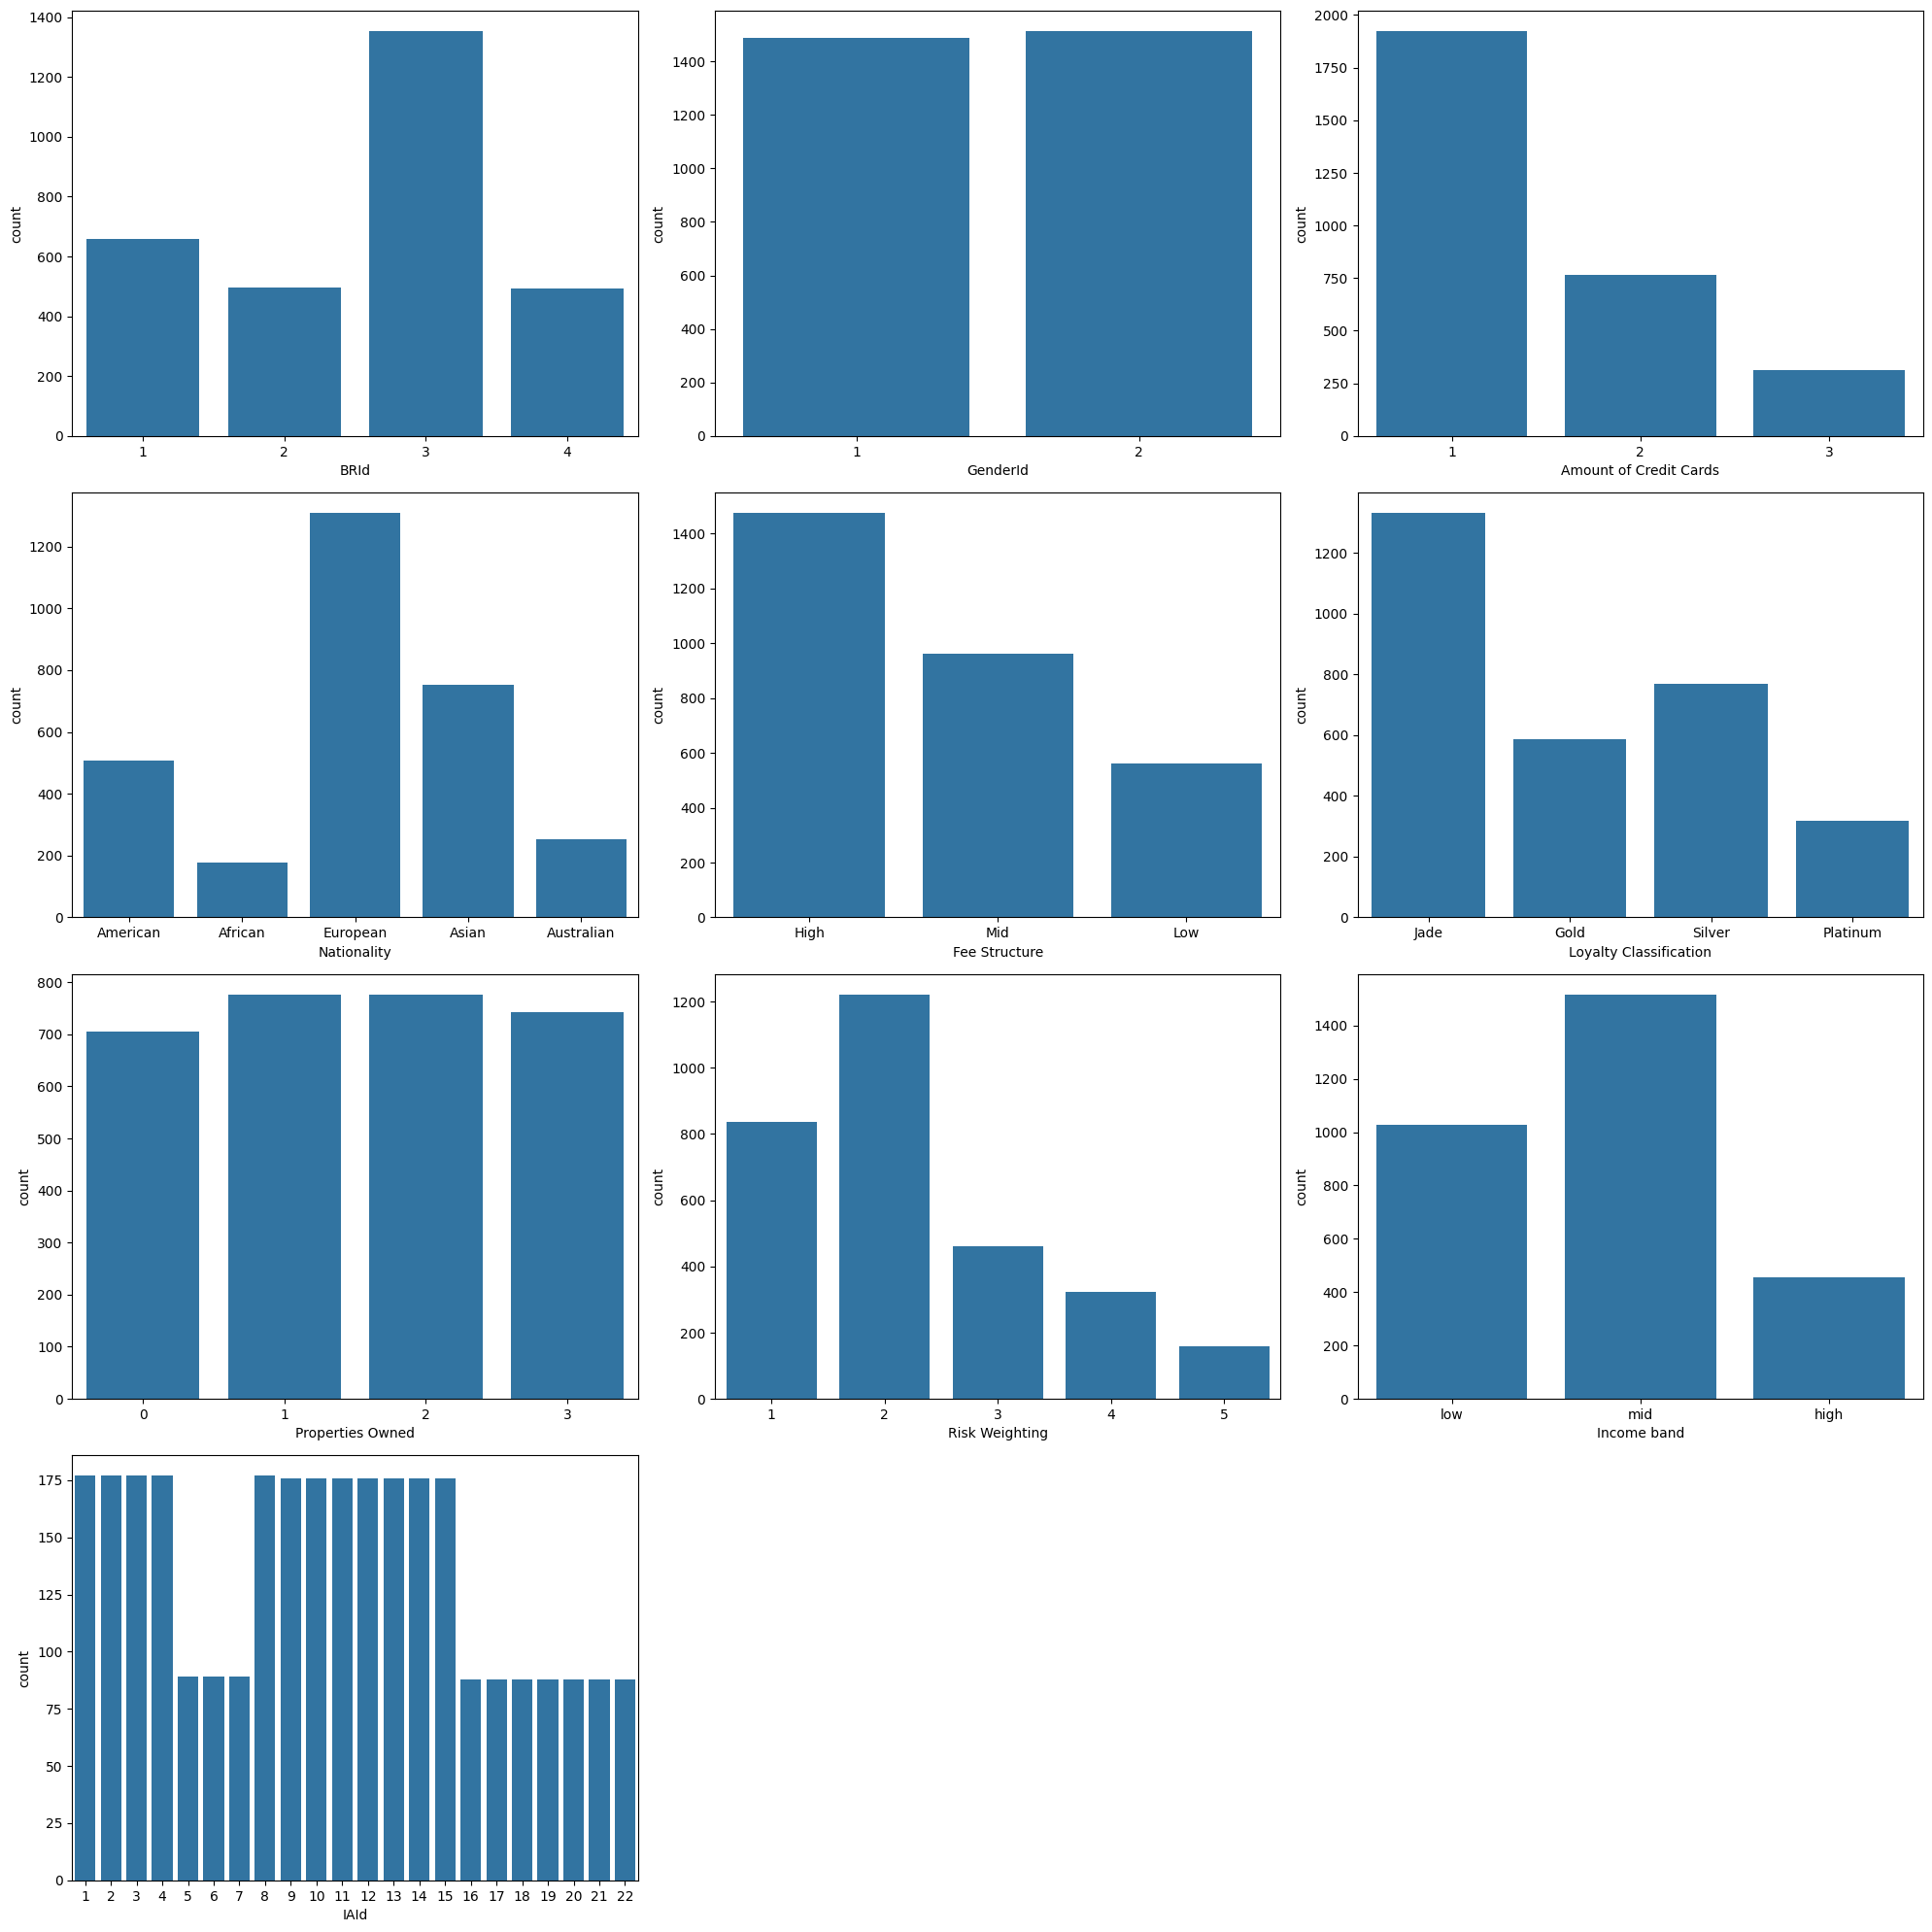

In [33]:
plt.figure(figsize = (20,20), facecolor = "white")
plotnumber = 1
for col in categorical_col:
    if plotnumber < 12 :
        ax = plt.subplot(4,3,plotnumber)
        sns.countplot(x=data[col])
    plotnumber+=1
plt.tight_layout()
plt.show()

In [57]:
# INSIGHTS
# Amount of Credit Cards: Most customers own only one credit card, indicating low multi-card adoption.
# Nationality: European customers form the largest customer segment, showing strong regional concentration.
# Fee Structure: A majority of customers fall under the high fee structure, suggesting preference for premium banking services.
# Loyalty Classification: Gold loyalty customers dominate the dataset, indicating strong mid-tier customer retention.
# Risk Weighting: Most customers belong to the medium-risk category, while high-risk customers are significantly fewer.
# Income Band: The customer base is primarily medium-income, with fewer high-income customers.
# Gender Distribution: Customer distribution is balanced across genders, reducing demographic bias in analysis.

## Bivariant analysis

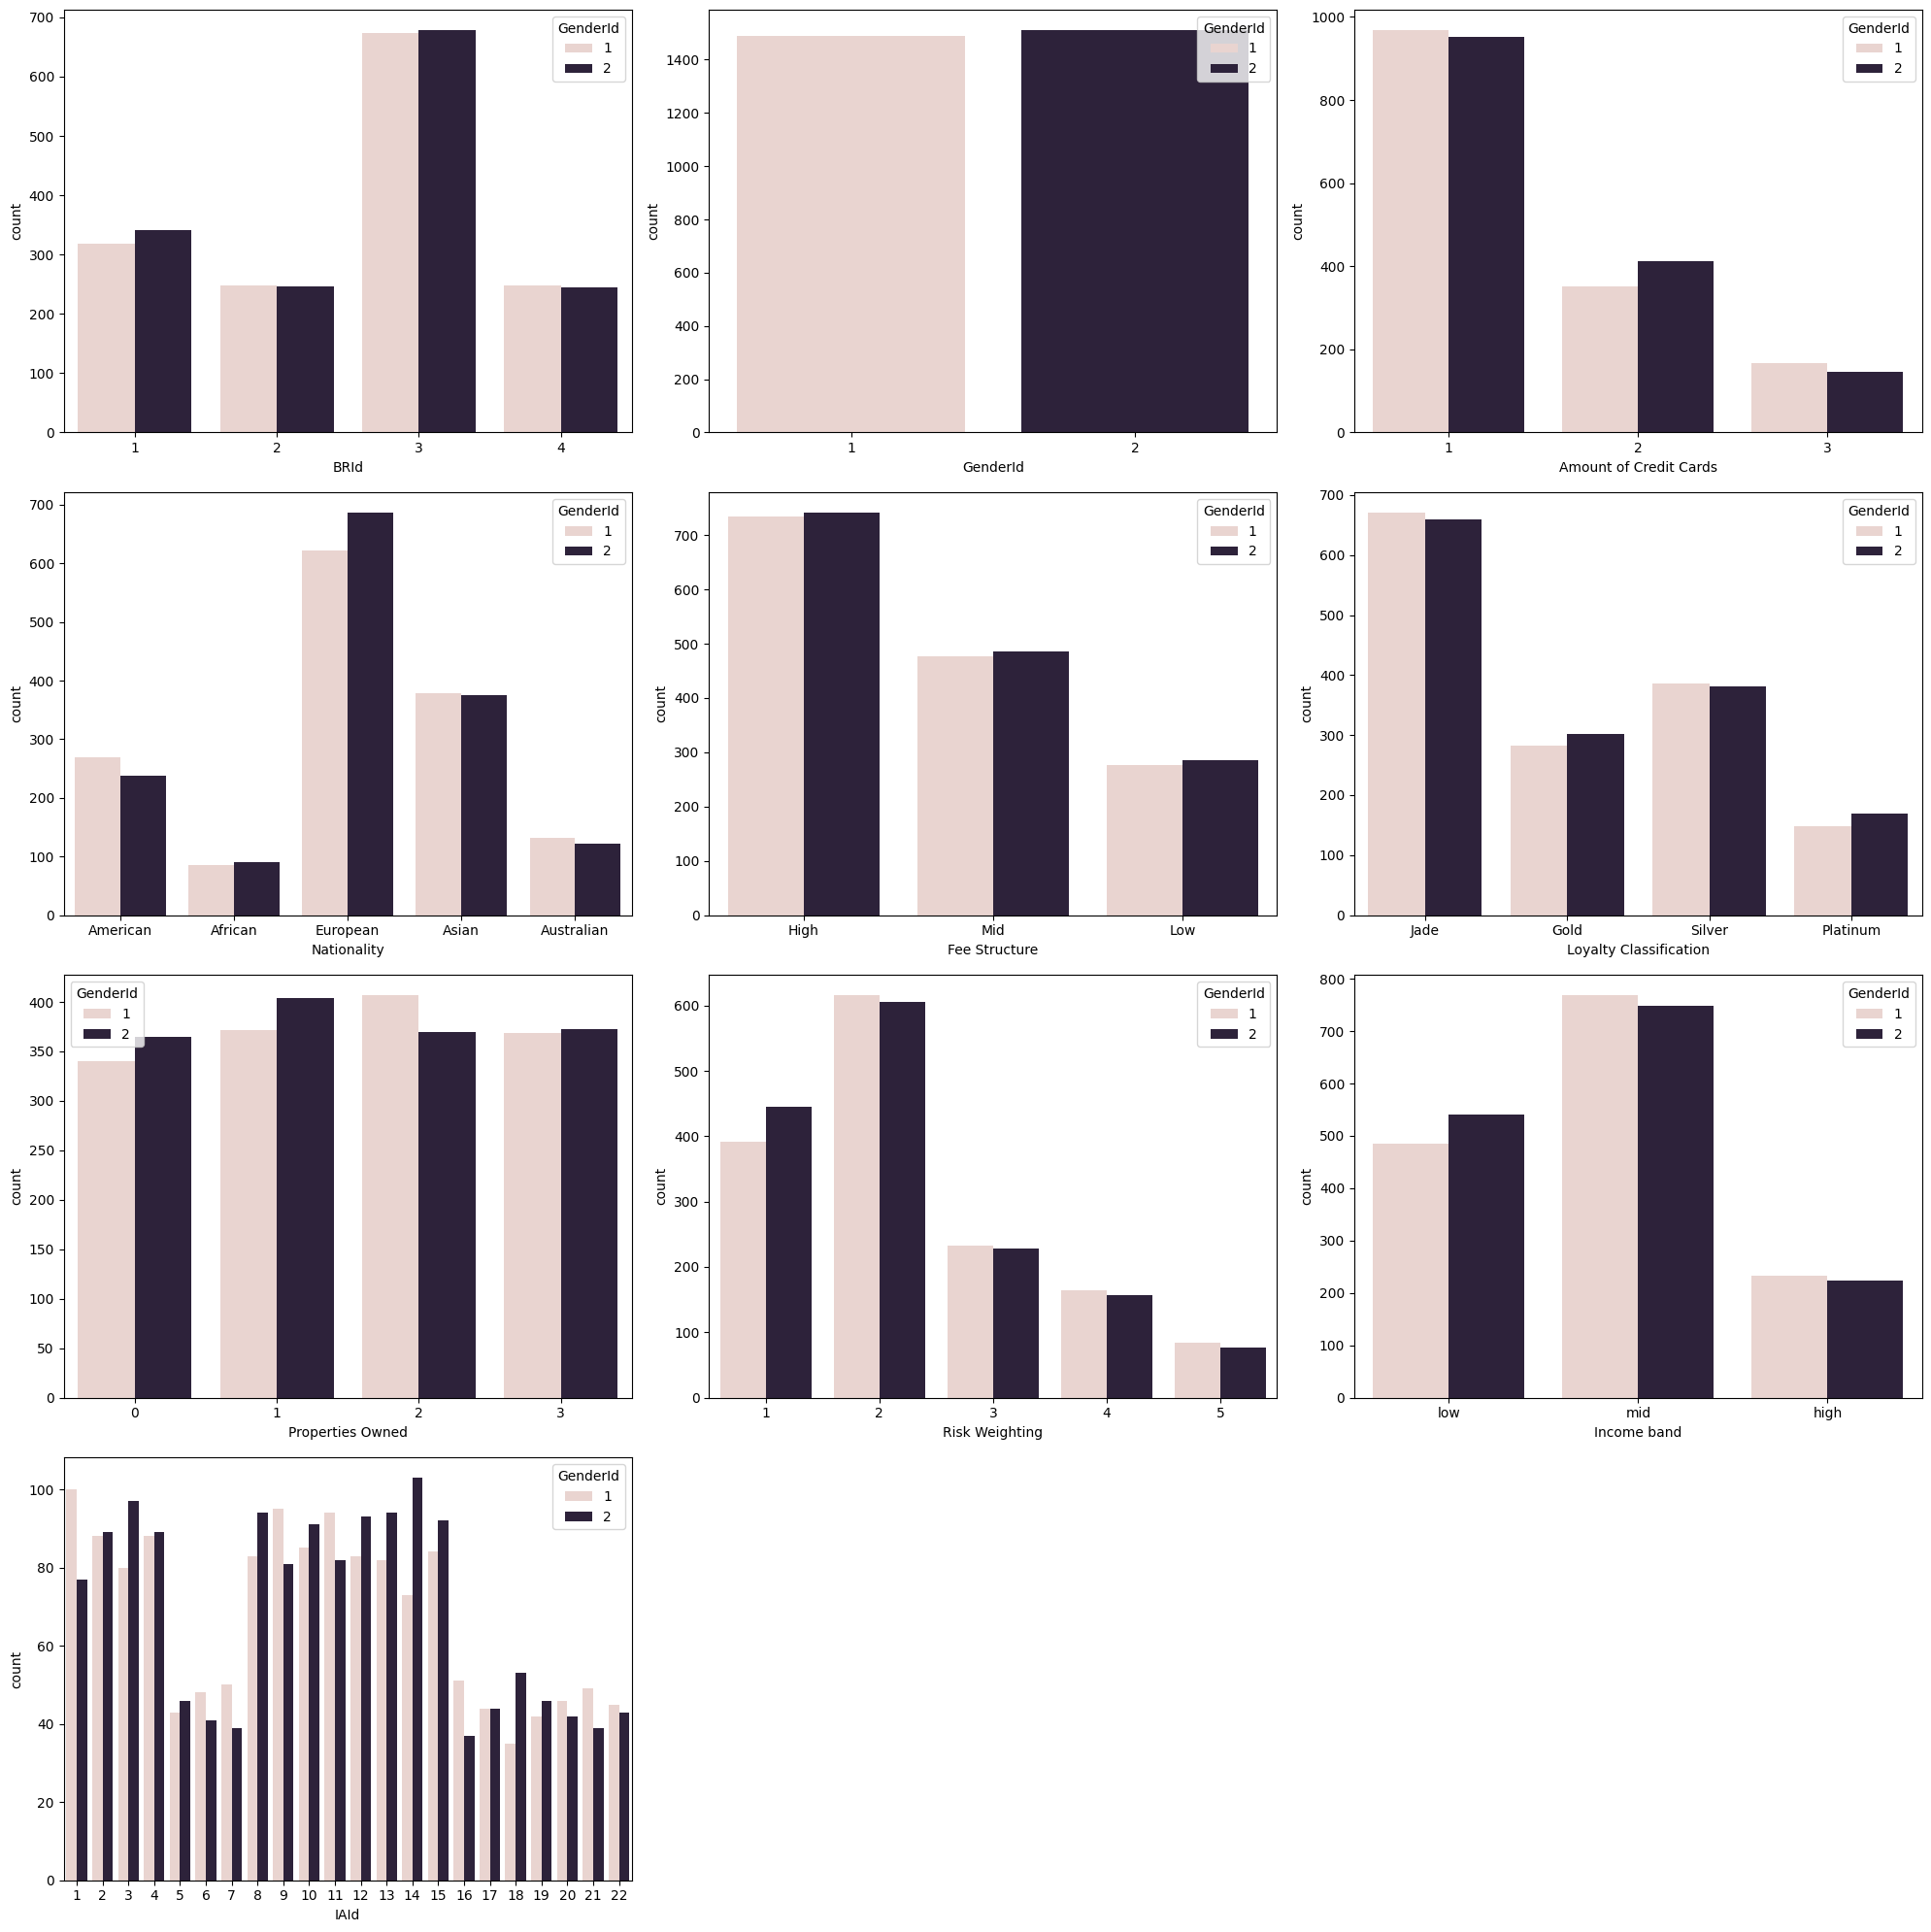

In [34]:
plt.figure(figsize = (20,20), facecolor = "white")
plotnumber = 1
for col in categorical_col:
    if plotnumber < 12 :
        ax = plt.subplot(4,3,plotnumber)
        sns.countplot(x=data[col], hue = data["GenderId"])
    plotnumber+=1
plt.tight_layout()
plt.show()

In [66]:
# INSIGHTS
# Amount of Credit Cards vs Gender: Both genders show similar behavior, with most customers owning only one credit card.
# Nationality vs Gender: European customers dominate for both genders, indicating a strong regional concentration regardless of gender.
# Fee Structure vs Gender: Both genders are highly concentrated in the high fee structure, suggesting similar premium service adoption.
# Loyalty Classification vs Gender: Gold loyalty membership is highest for both genders, showing similar retention behavior.
# Income Band vs Gender: Medium-income customers dominate across both genders, indicating comparable income distribution patterns.
# Properties Owned vs Gender: Property ownership patterns are fairly balanced across genders with no major variation.

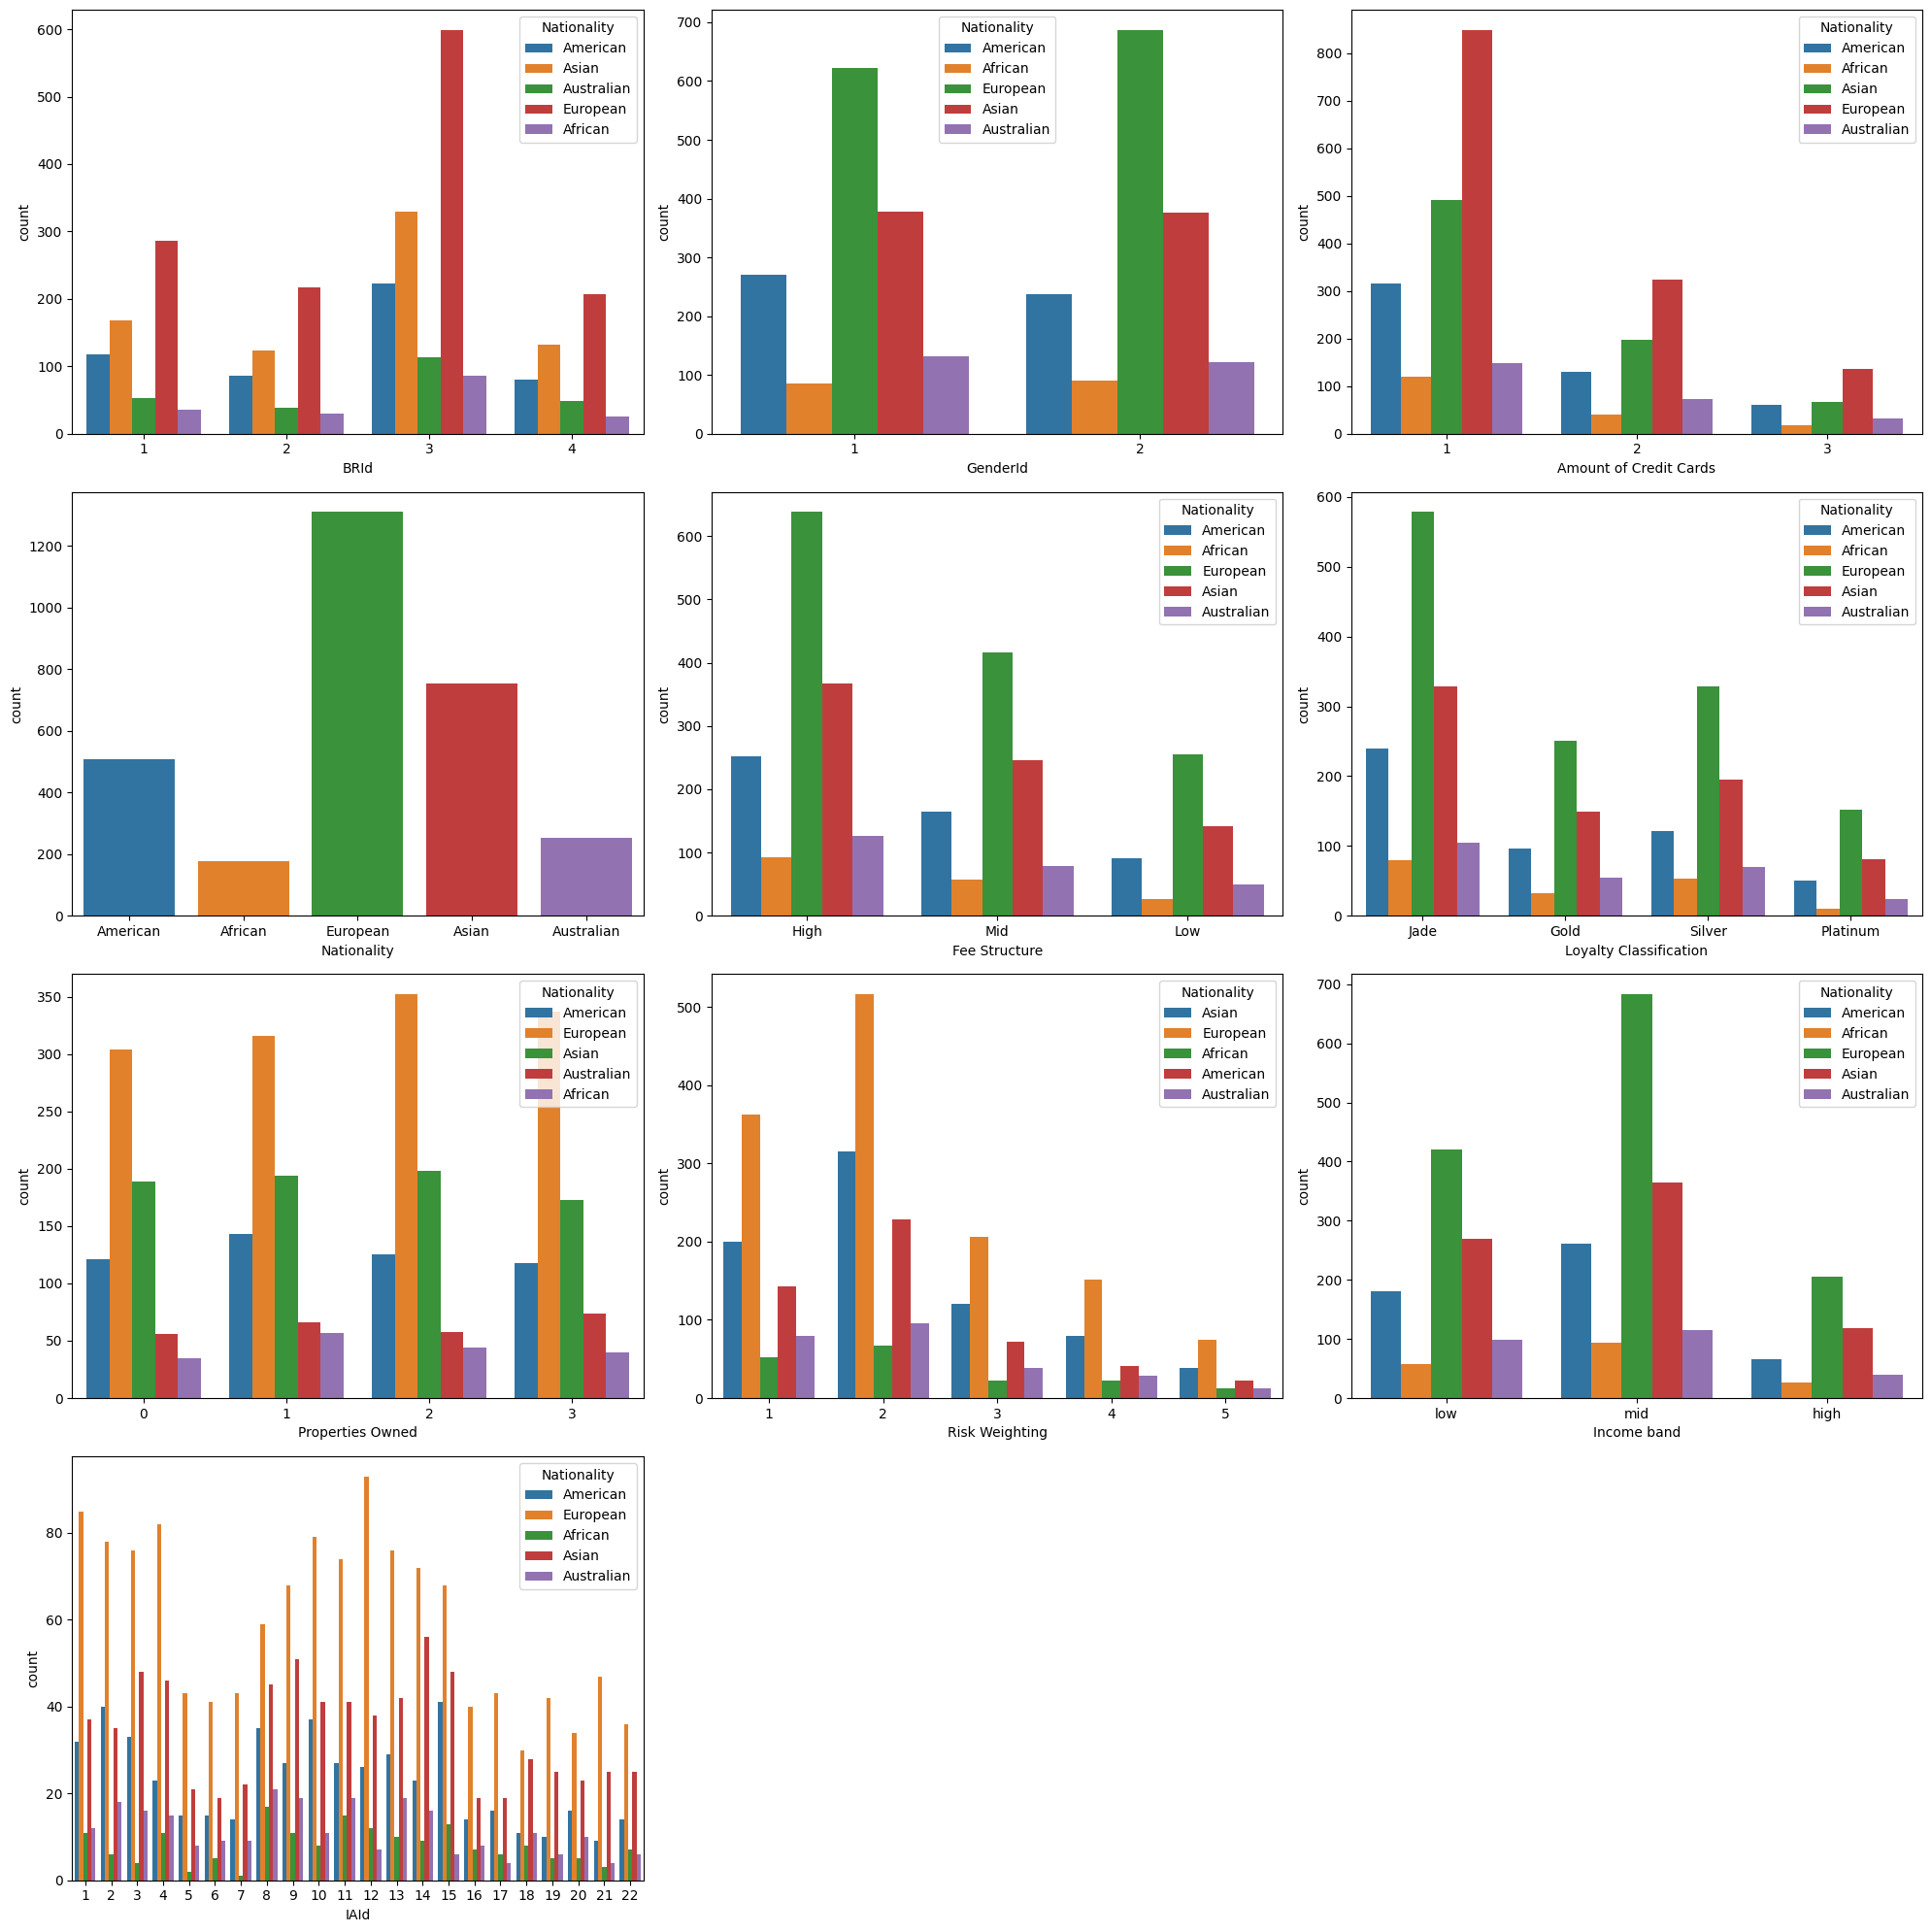

In [35]:
plt.figure(figsize = (20,20), facecolor = "white")
plotnumber = 1
for col in categorical_col:
    if plotnumber < 12 :
        ax = plt.subplot(4,3,plotnumber)
        sns.countplot(x=data[col], hue = data["Nationality"])
    plotnumber+=1
plt.tight_layout()
plt.show()

In [64]:
# INSIGHTS
# Amount of Credit Cards vs Nationality: European customers dominate across all credit card categories, with most holding only one credit card.
# Gender vs Nationality: European and Asian customers form the largest customer segments across both genders.
# Loyalty Classification vs Nationality: European customers have the highest counts across all loyalty levels, especially in the jade tier.
# Risk Weighting vs Nationality: African customers appear more concentrated in medium-risk categories, while higher risk groups remain smaller overall.
# Income Band vs Nationality: European customers dominate the medium-income segment, making them the primary customer base.
# Properties Owned vs Nationality: Property ownership is highest among European customers compared to other nationalities.

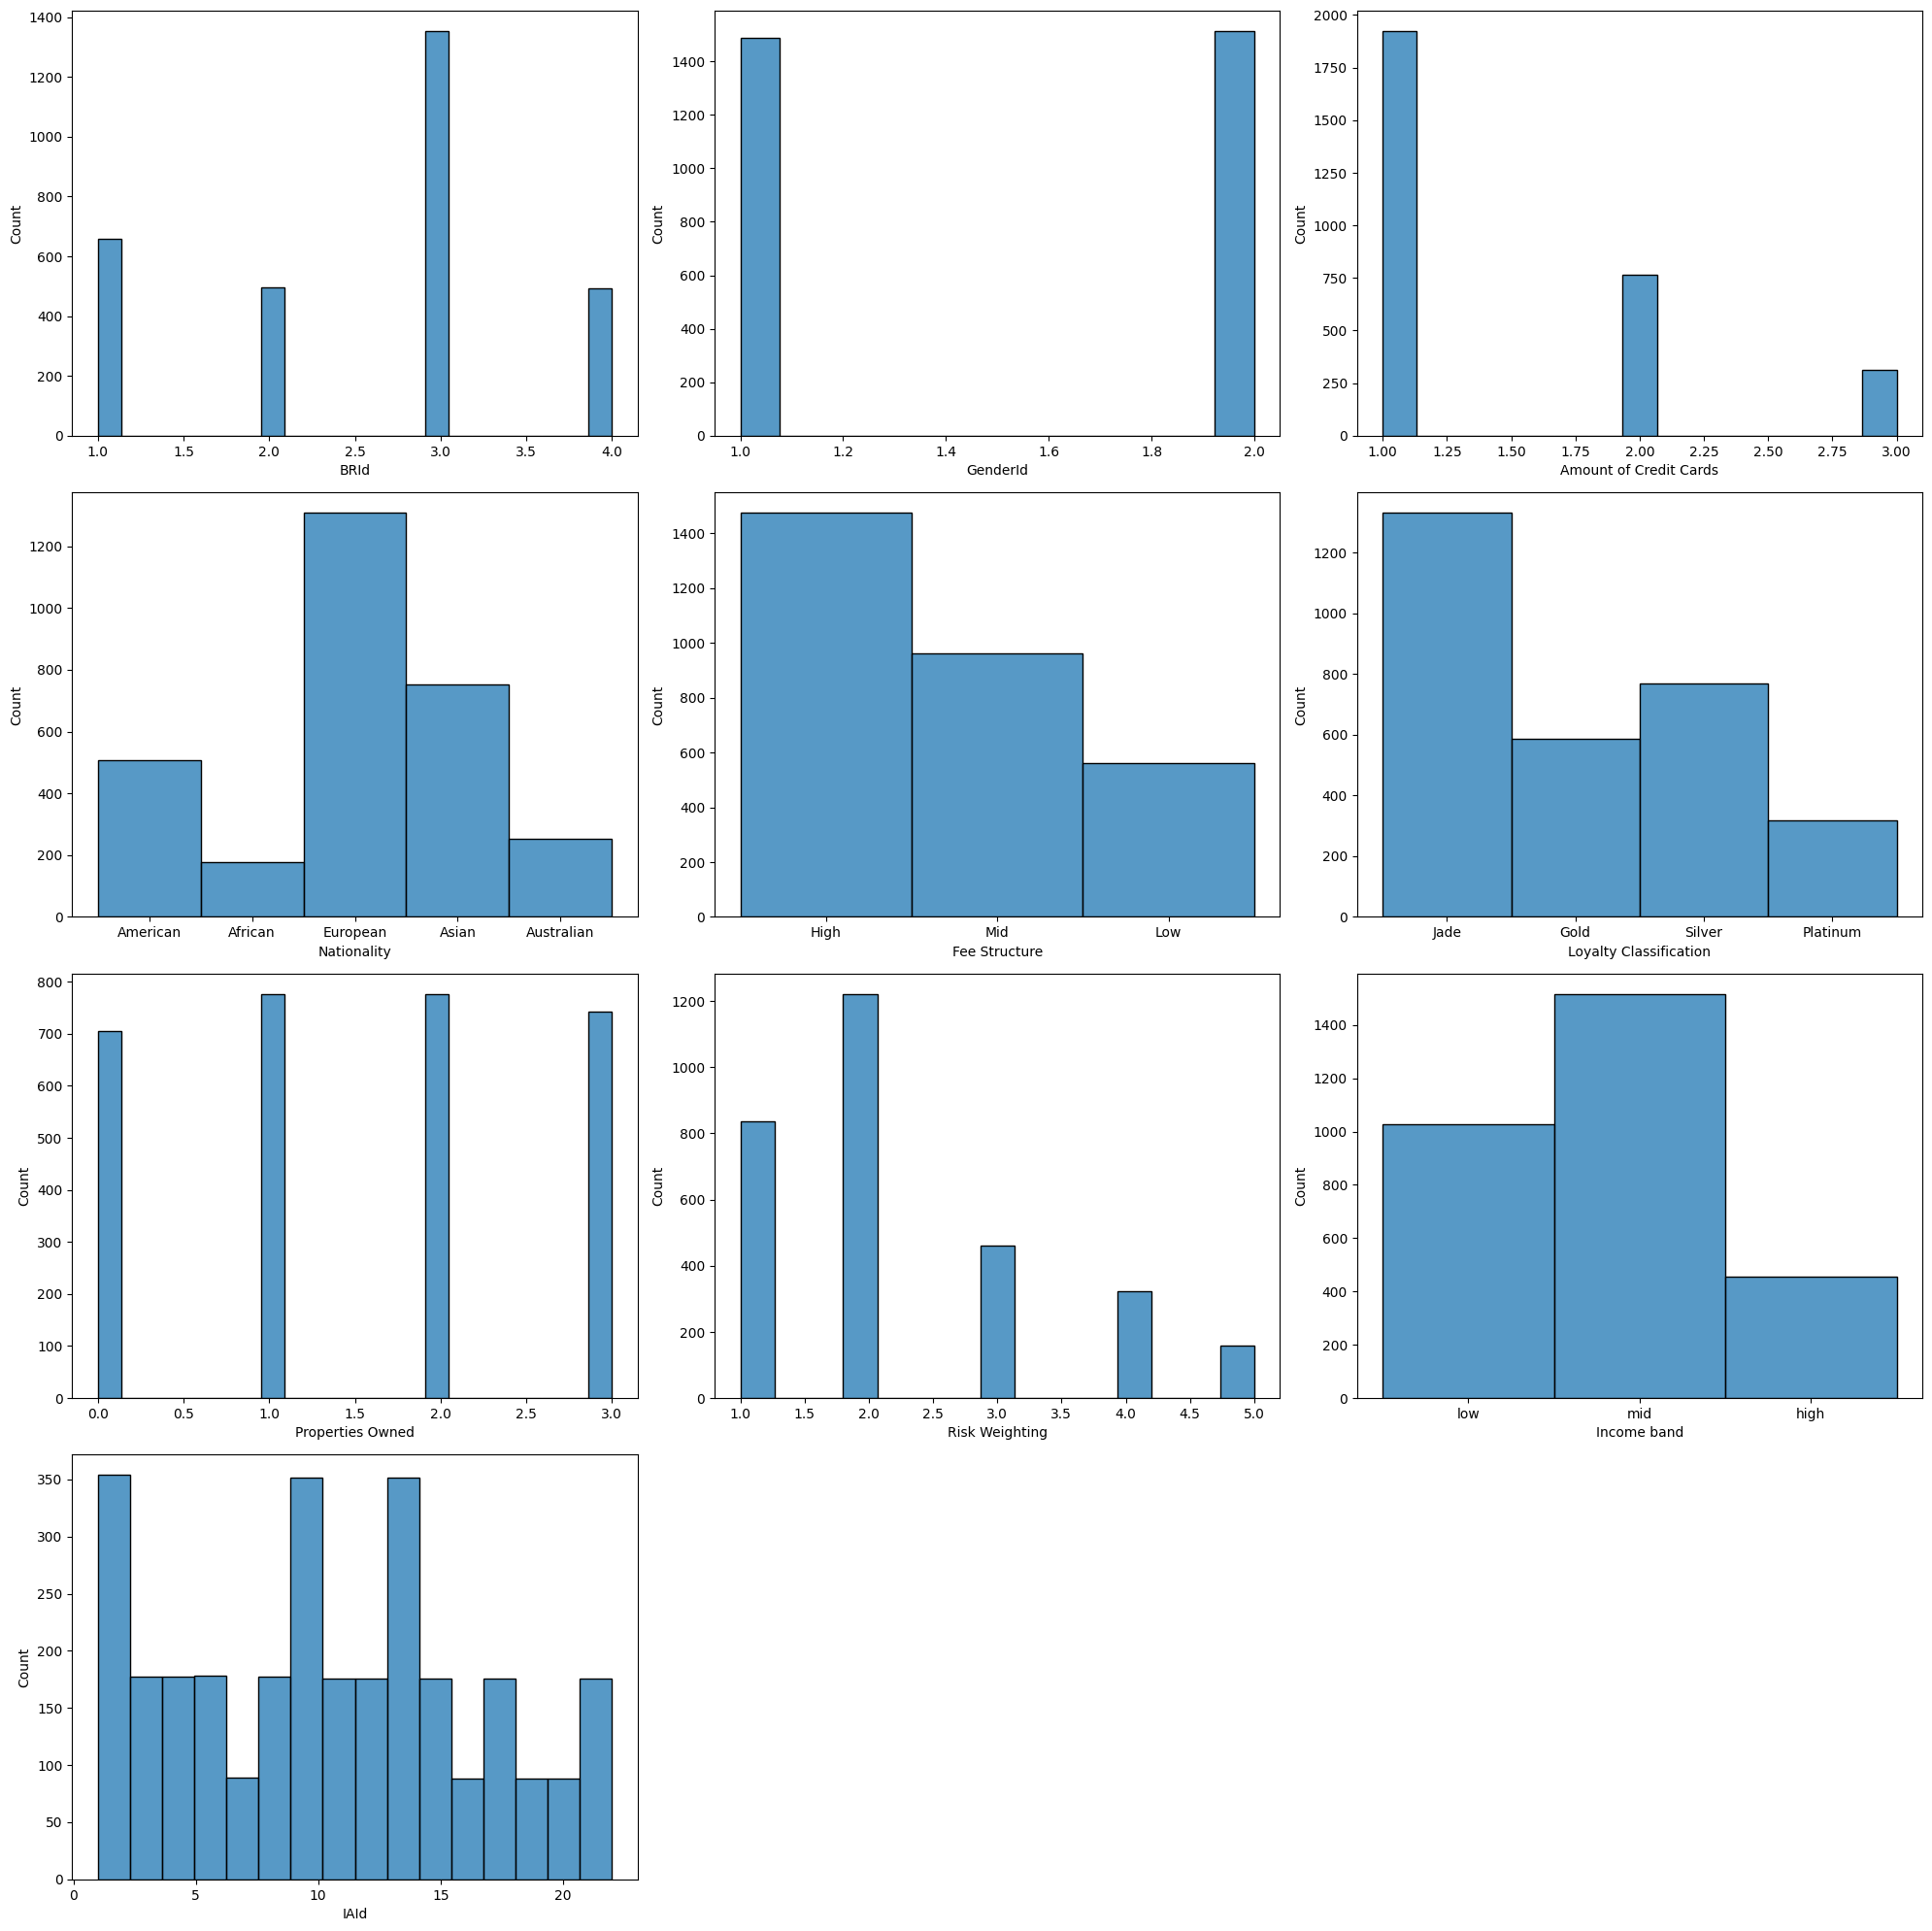

In [59]:
plt.figure(figsize = (20,20), facecolor = "white")
plotnumber = 1
for col in categorical_col:
    if plotnumber < 12 :
        ax = plt.subplot(4,3,plotnumber)
        sns.histplot(x=data[col])
    plotnumber+=1
plt.tight_layout()
plt.show()

In [65]:
# INSIGHTS
# Gender Distribution: The dataset is balanced across genders, ensuring less demographic bias in analysis.
# Amount of Credit Cards: Most customers hold only one credit card, indicating limited multi-card ownership.
# Nationality: European customers represent the largest customer segment, followed by Asian customers.
# Loyalty Classification: Jade loyalty customers dominate, while Platinum customers form the smallest segment.
# Income Band: The customer base is primarily medium-income, followed by low-income customers.

## Numerical columns

In [54]:
numerical_col = ["Estimated Income", "Superannuation Savings", "Credit Card Balance", "Bank Loans", "Bank Deposits", 
                 "Checking Accounts", "Saving Accounts", "Foreign Currency Account", "Business Lending"]

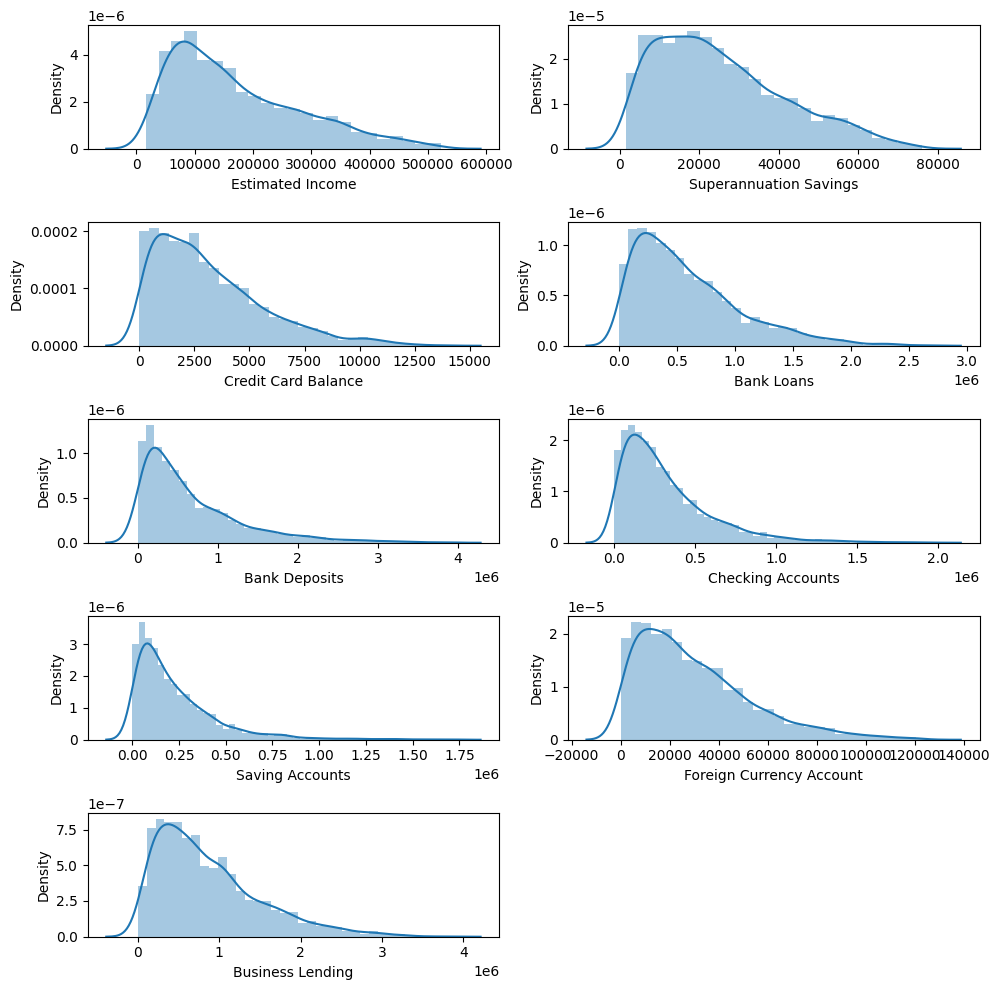

In [51]:
plt.figure(figsize = (10,10), facecolor = "white")
plotnumber = 1
for col in numerical_col:
    if plotnumber < 10 :
        ax = plt.subplot(5,2,plotnumber)
        sns.distplot(data[col])
    plotnumber+=1
plt.tight_layout()
plt.show()

In [62]:
# INSIGHTS
# Estimated Income: Income distribution is right-skewed, with most customers in lower-to-medium income ranges and a few high-income outliers.
# Credit Card Balance: Most customers maintain lower credit card balances, indicating manageable credit usage.
# Bank Loans: Loan amounts are heavily right-skewed, showing most customers have smaller loans while a few hold large borrowings.
# Bank Deposits: The majority of customers maintain lower deposit balances, with a small high-value customer segment.
# Saving Accounts: Most customers have moderate savings balances, with fewer customers holding very large savings.

## Heatmap

<Axes: >

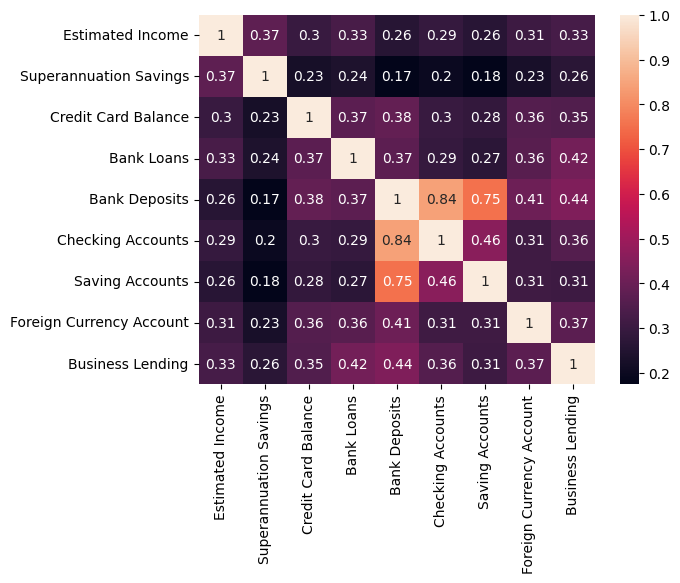

In [56]:
sns.heatmap(data[numerical_col].corr(), annot = True)

In [63]:
# INSIGHTS
# Bank Deposits and Checking Accounts show a strong positive correlation (0.84), indicating customers with higher deposits tend to maintain higher checking balances.
# Bank Deposits and Saving Accounts have a strong positive correlation (0.75), suggesting customers with higher deposits also maintain larger savings.
# Business Lending and Bank Loans show a moderate positive correlation (0.42), indicating customers with higher loans are more likely to have business lending exposure.
# Overall, most other variables show weak to moderate correlations, suggesting limited strong linear relationships across financial features.